## Big Project for PDFA module
Author Cathal Redmond
Date 22 Dec 2025. (Ho Ho Ho.)


In [52]:
## Big Project 
## I am opting to do the suggested wind farm data analysis project.
## I will select the closest data set to my location in Enniscorthy Co. Wexford, which is the Johnstown Castle data set.


In [53]:
##imports
import numpy as np
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests
from datetime import datetime, timedelta

In [54]:
# define a function to download and extract data from Met Eireann historical data website
def download_data():
    url = "https://cli.fusio.net/cli/climate_data/webdata/hly1775.zip"
    r = requests.get(url)
    zip_ref = ZipFile(BytesIO(r.content))
    
    dataframes = []
    
    for name in zip_ref.namelist():
        if name.endswith('.csv'):  # Only process CSV files
            print(f"Processing {name}")
            with zip_ref.open(name) as file_contents:
                df = pd.read_csv(file_contents, delimiter=',', skiprows=13, header=3, on_bad_lines='skip')
                dataframes.append(df)
    
    # Concatenate all dataframes into one
    if dataframes:
        combined_df = pd.concat(dataframes, ignore_index=True)
    else:
        combined_df = pd.DataFrame()
    
    print("Data loaded into DataFrame successfully")
    return combined_df

# place the data into a dataframe
# this will be useful as we will need to work with the data. 

dfjohnstown = download_data()
print(dfjohnstown.head())

Processing hly1775.csv
Data loaded into DataFrame successfully
                date  ind rain  ind.1 temp  ind.2 wetb dewpt vappr rhum msl  \
0  12-aug-2003 01:00   -1           4           4                             
1  12-aug-2003 02:00   -1           4           4                             
2  12-aug-2003 03:00   -1           4           4                             
3  12-aug-2003 04:00   -1           4           4                             
4  12-aug-2003 05:00   -1           4           4                             

   ind.3 wdsp  ind.4 wddir  
0      7           7        
1      7           7        
2      7           7        
3      7           7        
4      7           7        


/tmp/ipykernel_2935/4057818524.py:13: DtypeWarning: Columns (2,4,6,7,8,9,10,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_contents, delimiter=',', skiprows=13, header=3, on_bad_lines='skip')


In [55]:
# calculate basic statistics on the wind speed column
wind_speed = pd.to_numeric(dfjohnstown['wdsp'], errors='coerce')  #convert to numeric, coerce errors to NaN
mean_wind_speed = wind_speed.mean()
max_wind_speed = wind_speed.max()
min_wind_speed = wind_speed.min()
print(f"Mean Wind Speed: {mean_wind_speed} Knots")
print(f"Max Wind Speed: {max_wind_speed} Knots")
print(f"Min Wind Speed: {min_wind_speed} Knots")

Mean Wind Speed: 8.12521764067269 Knots
Max Wind Speed: 35.0 Knots
Min Wind Speed: 0.0 Knots


In [56]:
# calculate average wind speeds for each month, day and hour
dfjohnstown['wdsp'] = pd.to_numeric(dfjohnstown['wdsp'], errors='coerce')
dfjohnstown['date'] = pd.to_datetime(dfjohnstown['date'], format='%d-%b-%Y %H:%M')
dfjohnstown.set_index('date', inplace=True)
Yearly_avg_wind = dfjohnstown['wdsp'].resample('Y').mean()
monthly_avg_wind = dfjohnstown['wdsp'].resample('ME').mean()
daily_avg_wind = dfjohnstown['wdsp'].resample('D').mean()
hourly_avg_wind = dfjohnstown['wdsp'].resample('h').mean()  


/tmp/ipykernel_2935/2084032199.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  Yearly_avg_wind = dfjohnstown['wdsp'].resample('Y').mean()


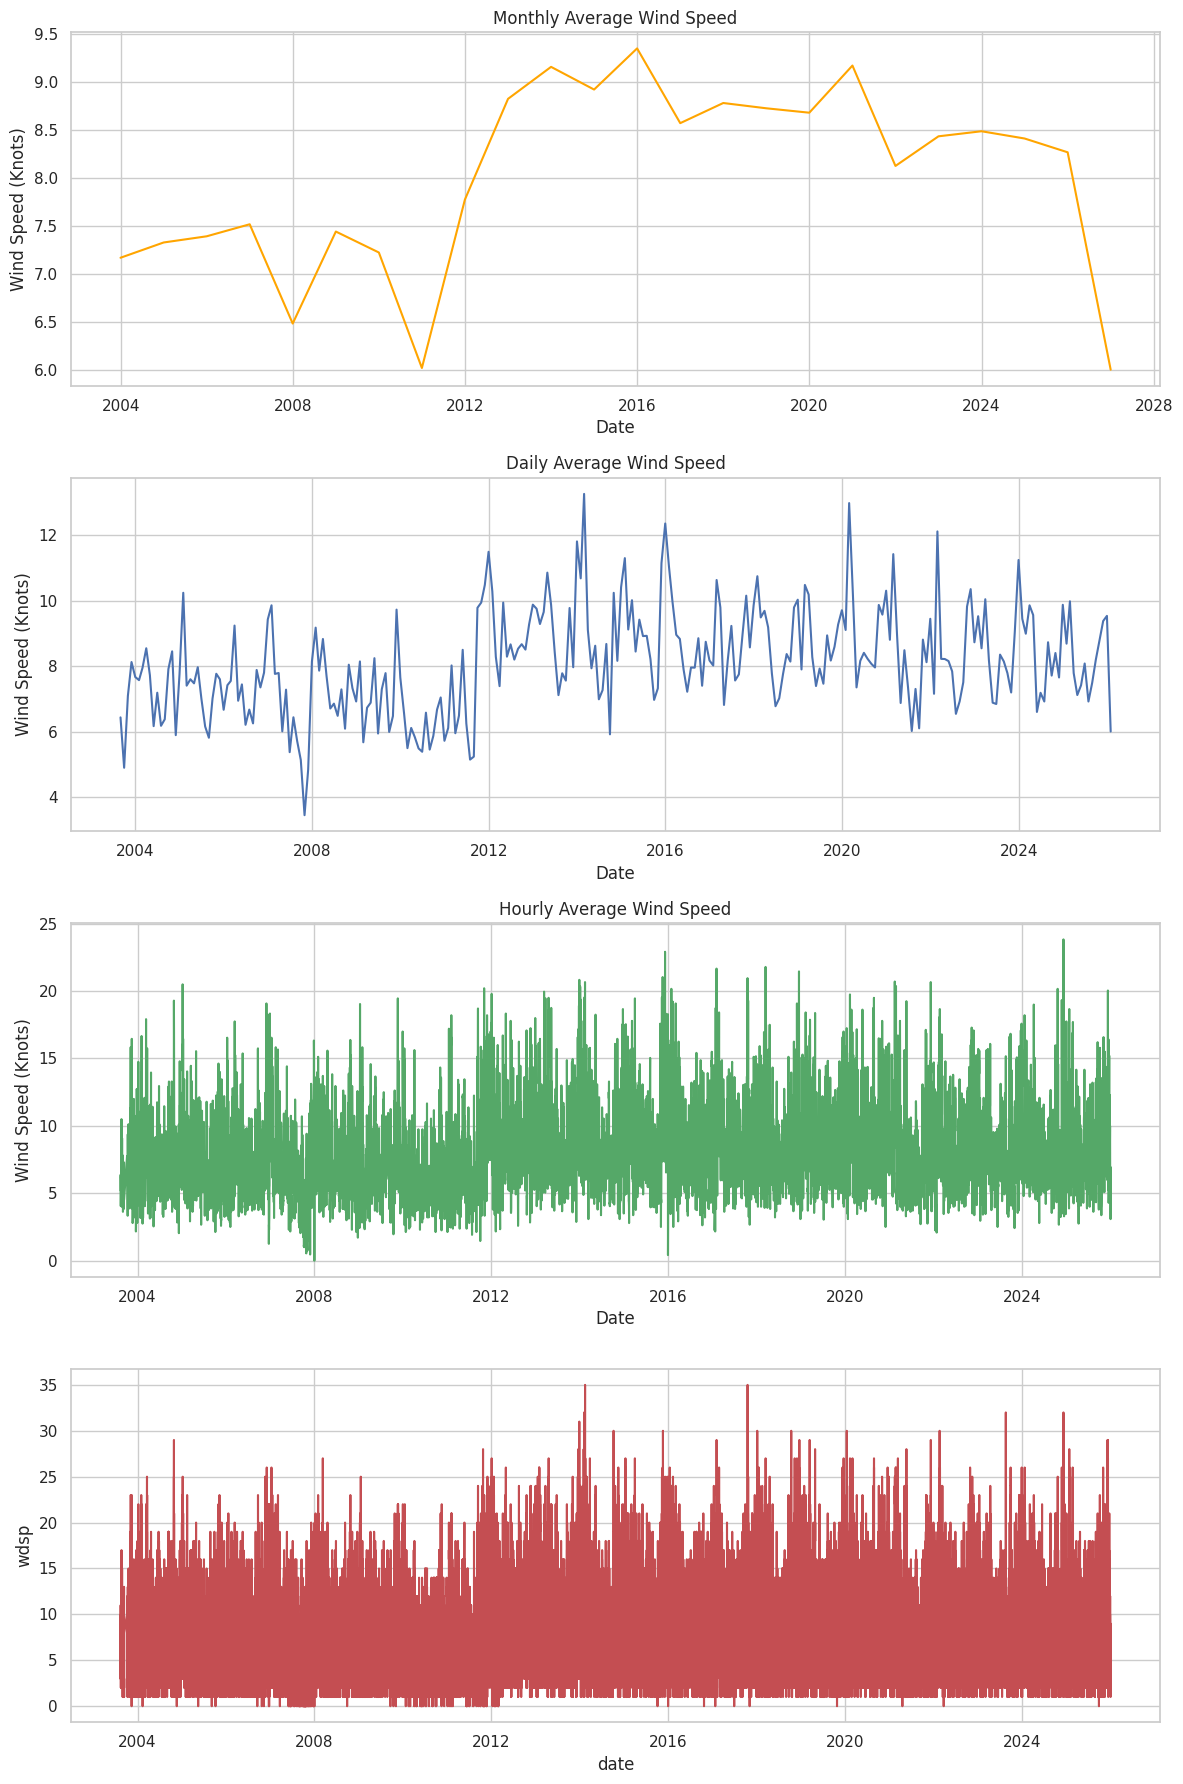

In [57]:
# plot the average wind speeds using seaborn using three subplots for monthly, daily and hourly averages

import seaborn as sns 
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

fig, axes = plt.subplots(4, 1, figsize=(12, 18))

sns.lineplot(data=Yearly_avg_wind, ax=axes[0], color='orange')
axes[0].set_title('Year Average Wind Speed')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Wind Speed (Knots)')

sns.lineplot(data=monthly_avg_wind, ax=axes[1], color='b')
axes[0].set_title('Monthly Average Wind Speed')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Wind Speed (Knots)')

sns.lineplot(data=daily_avg_wind, ax=axes[2], color='g')
axes[1].set_title('Daily Average Wind Speed')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Wind Speed (Knots)')

sns.lineplot(data=hourly_avg_wind, ax=axes[3], color='r')
axes[2].set_title('Hourly Average Wind Speed')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Wind Speed (Knots)')

plt.tight_layout()
plt.show()

#print(f"Monthly Average Wind Speeds:{monthly_avg_wind}")
#print(f"Daily Average Wind Speeds:{daily_avg_wind}")
#print(f"Hourly Average Wind Speeds:{hourly_avg_wind}")

* There seems to have been a step-change in recorded windspeed in December 2011/January 2012. The wind speed seems to be higher more frequently from this date forward. As there is no record of any global windspeed increase, this recorded increase is likely due to a change of measuring equipment, like an anemometer being replaced etc. 
* In response to the question asked: "Are windspeeds likely to be the same 10 years into the future?", I cant say with any degree of confidence whether the windspeed will remain largely in line with these observed records - i simply do not have enough information to predict this kind of certainty from this dataset. 
* A Study from Yale University in the USA suggests that global windspeeds will decline due to a phenomenon known as 'Global Stilling', but the local effects are subject to many factors affecting them. Link to Article: https://e360.yale.edu/features/global-stilling-is-climate-change-slowing-the-worlds-wind
* EPA publications support this claim, suggesting a decrease on the order of 1-3%.  Link to article published in CMIP6: https://www.epa.ie/publications/research/environmental-technologies/Research_Report_310_part3.pdf


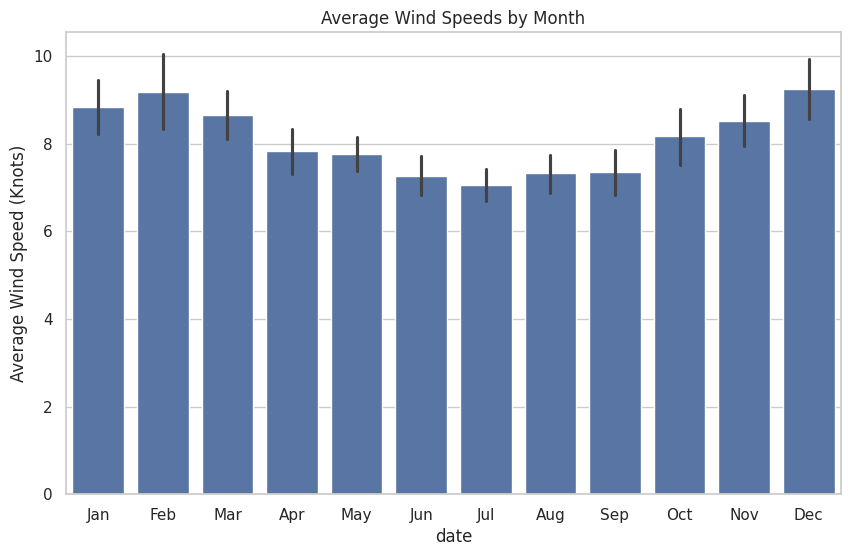

In [58]:
# show a barchart of the average wind speeds for each month
plt.figure(figsize=(10,6))
sns.barplot(x=monthly_avg_wind.index.month, y=monthly_avg_wind.values, color='b')
plt.title('Average Wind Speeds by Month')
plt.xticks(range(0,12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel('Average Wind Speed (Knots)')
plt.show()


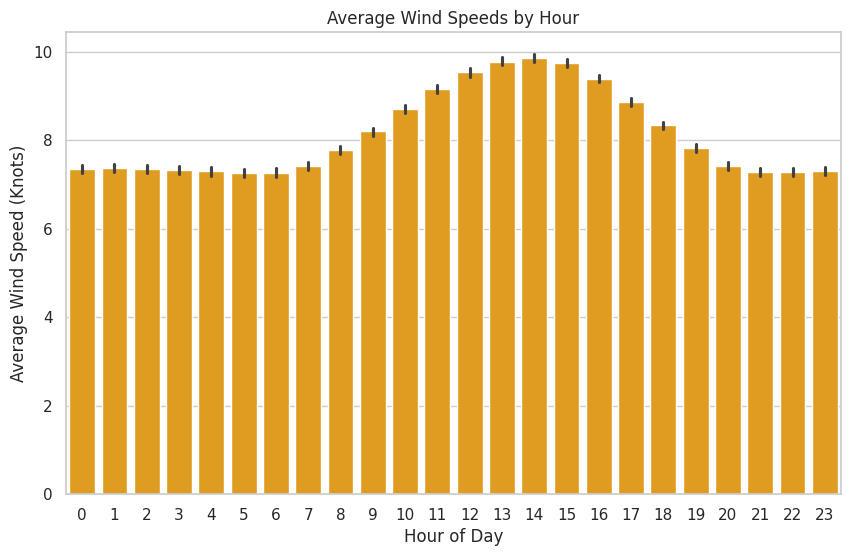

In [59]:
# show a barchart of the average wind speeds for each hour
plt.figure(figsize=(10,6))
sns.barplot(x=hourly_avg_wind.index.hour, y=hourly_avg_wind.values, color='orange')
plt.title('Average Wind Speeds by Hour')
plt.xticks(range(0,24), [str(i) for i in range(0,24)])
plt.ylabel('Average Wind Speed (Knots)')
plt.xlabel('Hour of Day')
plt.show()

* OK so i dont believe this graph is correct - i would not expect the hourly average wind to be as orderly as this, showing basically flat line between 9pm and 6am, and then a gradual increase to a peak at 2pm, and then gradual decline to 9pm again. 
* This looks much more like something related to daylight hours - possibly even might coincide with office hours - indicating a human record-keeping bias towards these times. 
* Investigate whether this is an artefact of the average sampling fucntion, by plotting the same graph from the raw data. 

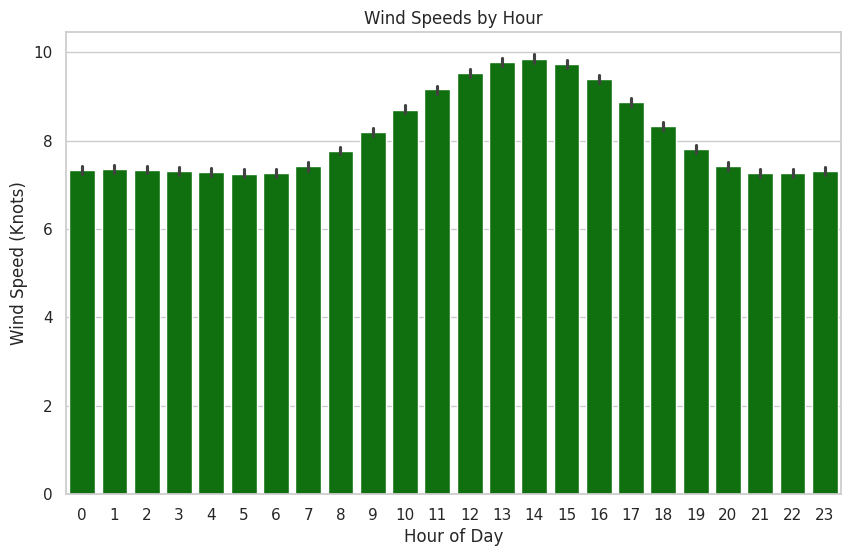

In [60]:
# show a barchart of the wind speeds for each hour
plt.figure(figsize=(10,6))
sns.barplot(x=dfjohnstown.index.hour, y=dfjohnstown['wdsp'], color='green')
plt.title('Wind Speeds by Hour')
plt.xticks(range(0,24), [str(i) for i in range(0,24)])
plt.ylabel('Wind Speed (Knots)')
plt.xlabel('Hour of Day')
plt.show()

Astonishigly, it seems the same pattern persists. 
* I have done some quick googling to see if there is an explanation for this observation, and it seems that there is a generalisable rule that afternoon time does seem to have higher windspeeds on average, due to the day starting out cooler and the air heating up as the sun warms the land throughout the day. This is highly dependant on local topography - Johnstown observation station in Wexford being costal may influence this. 
* Reference for this: Hartman, A.T. An analysis of the effects of temperatures and circulations on the strength of the low-level jet in the Turkana Channel in East Africa. Theor Appl Climatol 132, 1003–1017 (2018). https://doi.org/10.1007/s00704-017-2121-x

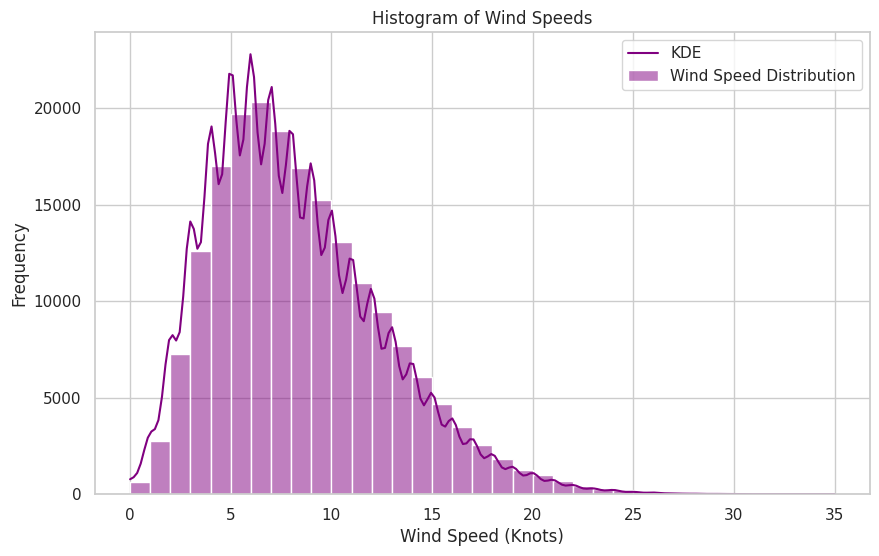

In [61]:
# Show histrogram of wind speeds for hourly average wind speed values. 
plt.figure(figsize=(10,6))
sns.histplot(dfjohnstown['wdsp'].dropna(), bins=35, kde=True, color='purple', stat = 'frequency')

plt.title('Histogram of Wind Speeds')
plt.xlabel('Wind Speed (Knots)')
plt.ylabel('Frequency')
plt.legend(['KDE','Wind Speed Distribution','Percentage of Occurances'])
plt.show()  

From this histogram chart we can extract a number of valuable insights. 
* Firstly, we can see the data follows a Right-Skewed histogram shape with its peak occuring at approximatelty 8 knots, indicating that the most frequently detected observation occurs at this wind speed. This will be a useful parameter when selecting the specific type of wind turbine for this location, as turbine selection is based largely on wind speed and consistency. 
* Approximately 85% of the observations were between 4 knots and 15 knots. 
* We see there are relatively fewer observations below 4 knots ~ 5%, and above 15 knots ~ 10%. 


* Note: we can see there is a Saw-tooth pattern visible in the Kernel Density Estimation line, which is an artefact of the data being sampled in integer values only. This can limit the usefulness of the data, as the frequency of windspeeds between each whole-number value are estimated to be lower than their likely physical occurance. 

In [62]:
# Quantifying Wind Variability. 
# Wind variability can be quantified using statistical measures such as standard deviation and coefficient of variation (CV).
# https://energy.sustainability-directory.com/term/wind-variability/#:~:text=Coefficient%20of%20Variation%20(CoV)%20%E2%86%92%20The%20CoV%2C,different%20locations%20with%20varying%20average%20wind%20speeds.

# Calculate standard deviation of wind speeds
std_dev = dfjohnstown['wdsp'].std()
print(f"Standard Deviation of Wind Speeds: {std_dev}")

# Calculate coefficient of variation (CV) 
cv = (std_dev / dfjohnstown['wdsp'].mean()) * 100
print(f"Coefficient of Variation: {cv}%")


Standard Deviation of Wind Speeds: 4.278999986222336
Coefficient of Variation: 52.66320454978085%


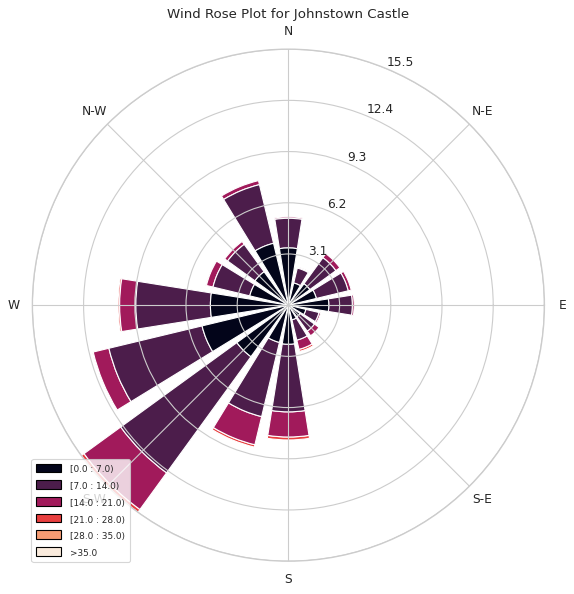

In [63]:
# generate wind rose plot to visualise wind direction and speed distribution
dfjohnstown['wddir'] = pd.to_numeric(dfjohnstown['wddir'], errors='coerce')
from windrose import WindroseAxes
ax = WindroseAxes.from_ax()
ax.bar(dfjohnstown['wddir'], dfjohnstown['wdsp'], normed=True, opening=0.8, edgecolor='white')
ax.set_title('Wind Rose Plot for Johnstown Castle')
ax.set_legend()
plt.show()

* We want to know how much power is available from the air in this location. This will be a multi-stage calculation where we use the humidity, air pressure and temperature to determine the density of the air, and then using the wind speed (converted to Meters per second).  
* We can then use another formula for calculating the power output of a hypothetical turbine to be placed on the location. 

For these calculation i have drawn heavily from the OMNI calculator physics air density calculator page, which is available to view at the link below:
https://www.omnicalculator.com/physics/air-density

In [64]:
# first we need to calculate the saturation vapor pressure using temperature and relative humidity
# calculate air saturation vapor pressure using temperature and relative humidity for each row in the dataframe
def calculate_saturation_vapor_pressure(temp_c, rhum):
    # Tetens formula
    es = 6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5))
    ea = (rhum / 100) * es
    return ea
dfjohnstown['temp'] = pd.to_numeric(dfjohnstown['temp'], errors='coerce')
dfjohnstown['rhum'] = pd.to_numeric(dfjohnstown['rhum'], errors='coerce')
dfjohnstown['saturation_vapor_pressure'] = dfjohnstown.apply(lambda row: calculate_saturation_vapor_pressure(row['temp'], row['rhum']), axis=1)
print(dfjohnstown[['temp', 'rhum', 'saturation_vapor_pressure']].tail())

                     temp  rhum  saturation_vapor_pressure
date                                                      
2025-12-31 20:00:00   3.4  75.0                   5.846840
2025-12-31 21:00:00   3.1  79.0                   6.029479
2025-12-31 22:00:00   3.2  74.0                   5.687953
2025-12-31 23:00:00   3.8  70.0                   5.613057
2026-01-01 00:00:00   3.8  69.0                   5.532870


In [65]:
# next we need to calclate the actual vapor pressure, using temperature only
# calculate actual vapor pressure using temperature for each row in the dataframe
def calculate_actual_vapor_pressure(temp_c):
    # Using Magnus formula for actual vapor pressure
    ea = 6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5))
    return ea
dfjohnstown['temp'] = pd.to_numeric(dfjohnstown['temp'], errors='coerce')
dfjohnstown['actual_vapor_pressure'] = dfjohnstown['temp'].apply(calculate_actual_vapor_pressure)
print(dfjohnstown[['temp', 'actual_vapor_pressure']].tail())    

                     temp  actual_vapor_pressure
date                                            
2025-12-31 20:00:00   3.4               7.795786
2025-12-31 21:00:00   3.1               7.632252
2025-12-31 22:00:00   3.2               7.686423
2025-12-31 23:00:00   3.8               8.018653
2026-01-01 00:00:00   3.8               8.018653


In [66]:
# Subtract Mean Sea Level pressure from saturation vapor pressure to get pressure of dry air. 
dfjohnstown['msl'] = pd.to_numeric(dfjohnstown['msl'], errors='coerce')
dfjohnstown['pressure_of_dry_air'] = dfjohnstown['msl'] - dfjohnstown['actual_vapor_pressure']
print(dfjohnstown[['msl', 'actual_vapor_pressure', 'pressure_of_dry_air']].tail())

                        msl  actual_vapor_pressure  pressure_of_dry_air
date                                                                   
2025-12-31 20:00:00  1025.6               7.795786          1017.804214
2025-12-31 21:00:00  1024.8               7.632252          1017.167748
2025-12-31 22:00:00  1023.9               7.686423          1016.213577
2025-12-31 23:00:00  1023.1               8.018653          1015.081347
2026-01-01 00:00:00  1022.8               8.018653          1014.781347


In [67]:
# calculate air density for the site using temperature and pressure of dry air data from the dataframe
# Air Density ρ = P / (R_specific * T)
# where:
# ρ = air density (kg/m³)
# P = atmospheric pressure (hPa)
R_specific = 287.05  # J/(kg·K)
dfjohnstown['temp_k'] = dfjohnstown['temp'] + 273.15  # Convert Celsius to Kelvin
dfjohnstown['air_density'] = dfjohnstown['pressure_of_dry_air'] * 100 / (R_specific * dfjohnstown['temp_k'])  # Convert hPa to Pa
print(dfjohnstown[['pressure_of_dry_air', 'temp_k', 'air_density']].tail()) 

                     pressure_of_dry_air  temp_k  air_density
date                                                         
2025-12-31 20:00:00          1017.804214  276.55     1.282133
2025-12-31 21:00:00          1017.167748  276.25     1.282723
2025-12-31 22:00:00          1016.213577  276.35     1.281056
2025-12-31 23:00:00          1015.081347  276.95     1.276856
2026-01-01 00:00:00          1014.781347  276.95     1.276479


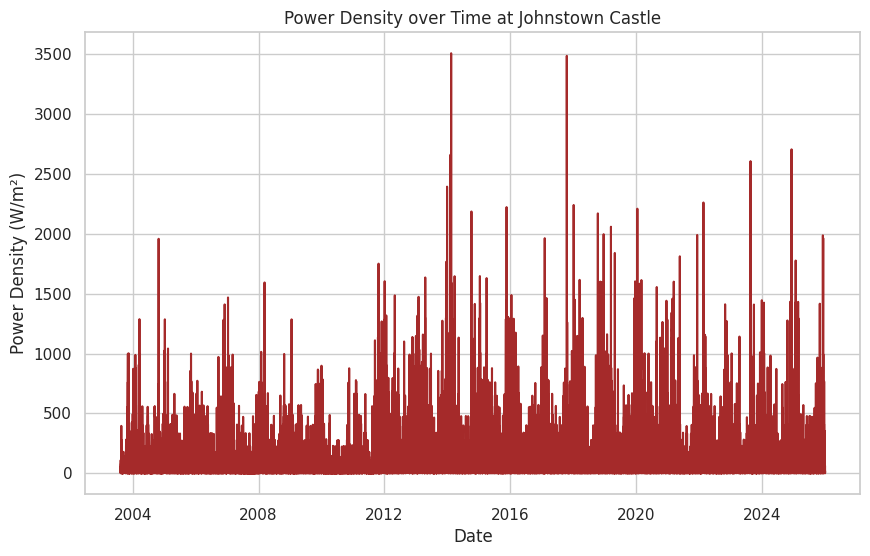

In [68]:
# calculate and plot power density of wind speeds
# Power density (W/m²) = 0.5 * air density (kg/m³) * (wind speed (m/s))^3
air_density = dfjohnstown['air_density']
# convert wind speed from knots to m/s (1 knot = 0.514444 m/s)
dfjohnstown['wdsp_mps'] = dfjohnstown['wdsp'] * 0.514444
dfjohnstown['power_density'] = 0.5 * air_density * (dfjohnstown['wdsp_mps'] ** 3)   
plt.figure(figsize=(10,6))  
sns.lineplot(data=dfjohnstown['power_density'], color='brown')
plt.title('Power Density over Time at Johnstown Castle')
plt.xlabel('Date')  
plt.ylabel('Power Density (W/m²)')
plt.show()




                     power_density  turbine_power
date                                             
2025-12-31 20:00:00       2.356574    1036.475466
2025-12-31 21:00:00       5.588523    2457.960781
2025-12-31 22:00:00       5.581260    2454.766448
2025-12-31 23:00:00      10.865163    4778.748465
2026-01-01 00:00:00      18.769454    8255.236851
Turbine Power Statistics:
count    1.946560e+05
mean     3.755157e+04
std      6.415506e+04
min      0.000000e+00
25%      0.000000e+00
50%      1.307360e+04
75%      4.787472e+04
max      1.543133e+06
Name: turbine_power, dtype: float64


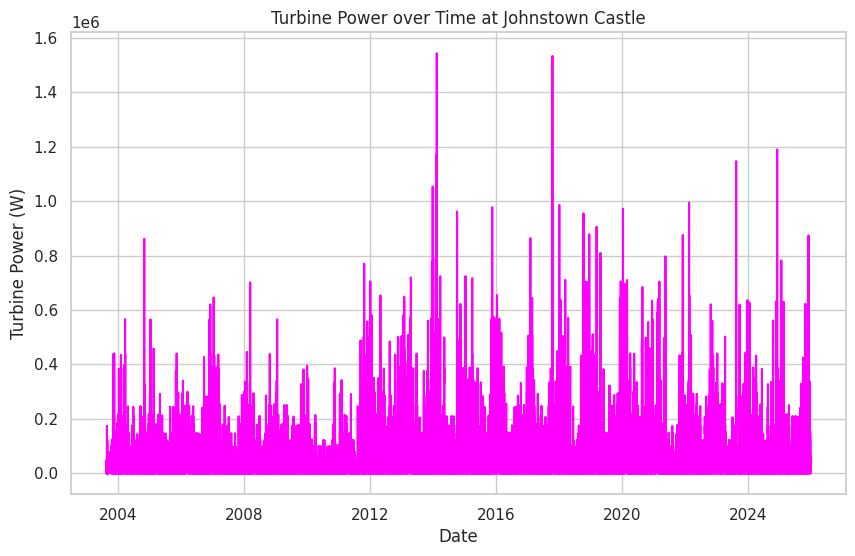

In [69]:
# calculate the power of a wind turbine at the site given a specific rotor diameter and efficiency
rotor_diameter = 40  # 40 meter turbines are common for installations in Ireland. 
efficiency = 0.35  # assume 35% efficiency for a modern wind turbine
swept_area = np.pi * (rotor_diameter / 2) ** 2  # m²
dfjohnstown['turbine_power'] = dfjohnstown['power_density'] * swept_area * efficiency
print(dfjohnstown[['power_density', 'turbine_power']].tail())   

# limit the turbine to operate only between cut-in and cut-out wind speeds
cut_in_speed = 3  # m/s
cut_out_speed = 25  # m/s
dfjohnstown.loc[(dfjohnstown['wdsp_mps'] < cut_in_speed) | (dfjohnstown['wdsp_mps'] > cut_out_speed), 'turbine_power'] = 0  

# plot the turbine power over time
plt.figure(figsize=(10,6))  
sns.lineplot(data=dfjohnstown['turbine_power'], color='magenta')
plt.xlabel('Date')  
plt.ylabel('Turbine Power (W)')
plt.title('Turbine Power over Time at Johnstown Castle')    

# show descriptive statistics for turbine power at the site
print(f"Turbine Power Statistics:\n{dfjohnstown['turbine_power'].describe()}")


* Calculate the percentage of turbine uptime for this location

In [70]:
# calculate the percentage of time the wind speed is within the operational range of the turbine
operational_time = dfjohnstown[(dfjohnstown['wdsp_mps'] >= cut_in_speed) & (dfjohnstown['wdsp_mps'] <= cut_out_speed)].shape[0]
total_time = dfjohnstown.shape[0]
operational_percentage = (operational_time / total_time) * 100
print(f"Percentage of Time Wind Speed is within Operational Range: {operational_percentage:.2f}%")

Percentage of Time Wind Speed is within Operational Range: 68.94%


In [71]:
# calcuate the total energy produced by the turbine over the data period
# Energy (Wh) = Power (W) * Time (h)
time_interval_hours = 1  # assuming data is hourly
dfjohnstown['energy_wh'] = dfjohnstown['turbine_power'] * time_interval_hours
total_energy_wh = dfjohnstown['energy_wh'].sum()
print(f"Total energy that could have been produced by the Turbine over time period measured: {total_energy_wh:.2E} Wh")

Total energy that could have been produced by the Turbine over time period measured: 7.31E+09 Wh


## Forecasts
There is data available for 10-days into the future from Met Eirann website at the following link: http://openaccess.pf.api.met.ie/metno-wdb2ts/locationforecast?lat=54.7210798611;long=-8.7237392806 where lat and long are the GPS coordinate locations for the given station. 

I will now process this link to download the data for the Johnstown Castle 2 weather location to estimate the wind speed for 10 days time (from the time the program is run)


In [72]:
# define a link for the forecast
forecast = 'http://openaccess.pf.api.met.ie/metno-wdb2ts/locationforecast?lat=52.298;long=-6.497237392806'

# define the date for ten days from now
ten_days_from_now = datetime.now() + timedelta(days=10)
print(f'Ten days from now is: {ten_days_from_now}')

# import the forecast data from the link above into a dataframe
import xml.etree.ElementTree as ET
response = requests.get(forecast)
root = ET.fromstring(response.text)
data = []
for time_elem in root.findall('.//time'):
    from_time = time_elem.get('from')
    wind_speed_elem = time_elem.find('.//windSpeed')
    wind_direction_elem = time_elem.find('.//windDirection')
    if wind_speed_elem is not None and wind_direction_elem is not None:
        data.append({
            'date': from_time,
            'wdsp': float(wind_speed_elem.get('mps')),
            'wddir': float(wind_direction_elem.get('deg'))
        })
df_forecast = pd.DataFrame(data)
df_forecast['date'] = pd.to_datetime(df_forecast['date']).dt.tz_localize(None)

# show the first 5 rows
print(df_forecast.head())    

# find the forecast closest to ten_days_from_now
if not df_forecast.empty:
    closest_idx = (df_forecast['date'] - ten_days_from_now).abs().idxmin()
    wind_speed_forecast = df_forecast.loc[closest_idx, 'wdsp']
    wind_direction_forecast = df_forecast.loc[closest_idx, 'wddir']
    forecast_date = df_forecast.loc[closest_idx, 'date']
    print(f'Forecasted Wind Speed for {forecast_date}: {wind_speed_forecast} m/s')
    print(f'Forecasted Wind Direction for {forecast_date}: {wind_direction_forecast} Degrees')
else:
    print("No forecast data found.")

Ten days from now is: 2026-01-21 23:34:50.336808
                 date  wdsp  wddir
0 2026-01-12 00:00:00  10.5  213.6
1 2026-01-12 01:00:00   9.2  215.6
2 2026-01-12 02:00:00   9.2  217.0
3 2026-01-12 03:00:00   9.1  213.7
4 2026-01-12 04:00:00   9.2  218.4
Forecasted Wind Speed for 2026-01-21 00:00:00: 0.4 m/s
Forecasted Wind Direction for 2026-01-21 00:00:00: 166.4 Degrees


In [73]:
# use this forecast to estimate the power output of the wind turbine at that time
# convert wind speed from m/s to knots (1 m/s = 1.94384 knots)
wind_speed_knots = wind_speed_forecast * 1.94384
# calculate power density   
power_density_forecast = 0.5 * air_density.mean() * (wind_speed_forecast ** 3)  # using mean air density
print(f'Estimated Power Density at {forecast_date}: {power_density_forecast} W/m²')

# calculate turbine power output at the forecasted wind speed
turbine_power_forecast = power_density_forecast * swept_area * efficiency
# limit the turbine to operate only between cut-in and cut-out wind speeds
if wind_speed_forecast < cut_in_speed or wind_speed_forecast > cut_out_speed:
    turbine_power_forecast = 0
print(f'Estimated Turbine Power Output at {forecast_date}: {turbine_power_forecast} W')

Estimated Power Density at 2026-01-21 00:00:00: 0.03936489020579239 W/m²
Estimated Turbine Power Output at 2026-01-21 00:00:00: 0 W


## End of code